#Experiment 4: CNN for Image Classification


In [20]:
# Step 1: Import Libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np


In [21]:
# Step 2: Load CIFAR-10 Dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values (0-255 -> 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']


In [22]:

# Step 3: Design CNN Architecture
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Flatten Layer
model.add(layers.Flatten())

# Fully Connected Layer
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

# Model Summary
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:

# Step 4: Compile Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 5: Train Model
history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_test, y_test))


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/step - accuracy: 0.3595 - loss: 1.7358 - val_accuracy: 0.5335 - val_loss: 1.2800
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.5669 - loss: 1.2170 - val_accuracy: 0.6030 - val_loss: 1.1246
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6352 - loss: 1.0388 - val_accuracy: 0.6489 - val_loss: 0.9936
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6757 - loss: 0.9303 - val_accuracy: 0.6718 - val_loss: 0.9385
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 43ms/step - accuracy: 0.7009 - loss: 0.8587 - val_accuracy: 0.6645 - val_loss: 0.9524
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.7218 - loss: 0.7905 - val_accuracy: 0.6879 - val_loss: 0.9080
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.7487 - loss: 0.7270 - val_accuracy: 0.6955 - val_loss: 0.8862
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 42ms/step - accuracy: 0.7615 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4352 - loss: 1.5480
Test Accuracy: 0.42899999022483826


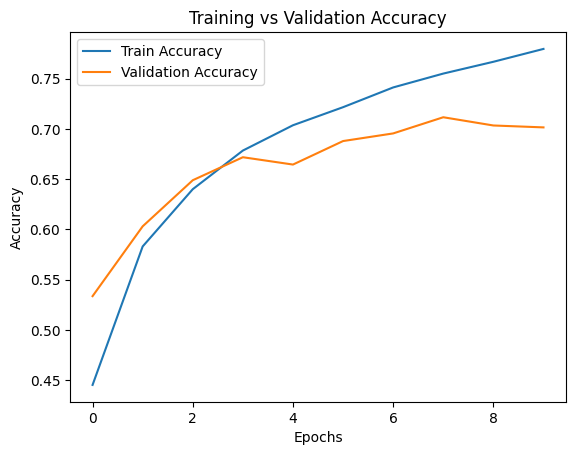

In [28]:


# Step 6: Evaluate Model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# Plot Training Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()

In [29]:
# Step 7: Extract Feature Maps

# Get outputs of convolution layers
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]

# Create a new model that returns these outputs
feature_map_model = tf.keras.models.Model(inputs=model.layers[0].input,
                                          outputs=layer_outputs)

# Use the same input image
sample_image = x_test[0].reshape(1,32,32,3)

# Generate feature maps
feature_maps = feature_map_model.predict(sample_image)

# Print feature map details
for i, fmap in enumerate(feature_maps):
    print(f"Feature Map from Conv Layer {i+1}")
    print("Shape:", fmap.shape)
    print("Number of Filters:", fmap.shape[-1])
    print("-"*40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Feature Map from Conv Layer 1
Shape: (1, 30, 30, 32)
Number of Filters: 32
----------------------------------------
Feature Map from Conv Layer 2
Shape: (1, 13, 13, 64)
Number of Filters: 64
----------------------------------------
Feature Map from Conv Layer 3
Shape: (1, 4, 4, 64)
Number of Filters: 64
----------------------------------------
